## 1. Exploratory Data Analysis (EDA) & Data Cleaning

###### *Libraries*

In [98]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import math
import os

##### **0. Importing & Sanitization**

In [72]:
data = pd.read_csv('../data/raw/data.csv', sep=';')

data.columns = (
    data.columns
    .str.strip()        
    .str.replace('\t', '', regex=False)  
)

Numerical_data = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

Categorical_data = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]
numeric_cols = [col for col in Numerical_data if col in data.columns]
print("Dataset Loaded Correctly. Shape:", data.shape)
print(f"A number of {len(numeric_cols)} real numerical columns have been detected.")

Dataset Loaded Correctly. Shape: (4424, 37)
A number of 18 real numerical columns have been detected.


##### **1. Data Quality & Integrity**
##### **1.1 Null & Duplicate values identification**

In [73]:
null_counts = data.isnull().sum().sum()
duplicate_counts = data.duplicated().sum()

print('Number of null values in the whole dataset:', null_counts)
print('Number of duplicate values in the whole dataset:', duplicate_counts)

Number of null values in the whole dataset: 0
Number of duplicate values in the whole dataset: 0


In [74]:
print('Dataset information:')
data.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification         

##### **1.2 Outlier Identification**
To choose the outliers that should be eliminated, we must use only numerical variables, because if we use categorical variables, we would probably eliminate data that is not atypical, since, for example, nationality is represented by an identification number that varies a lot.

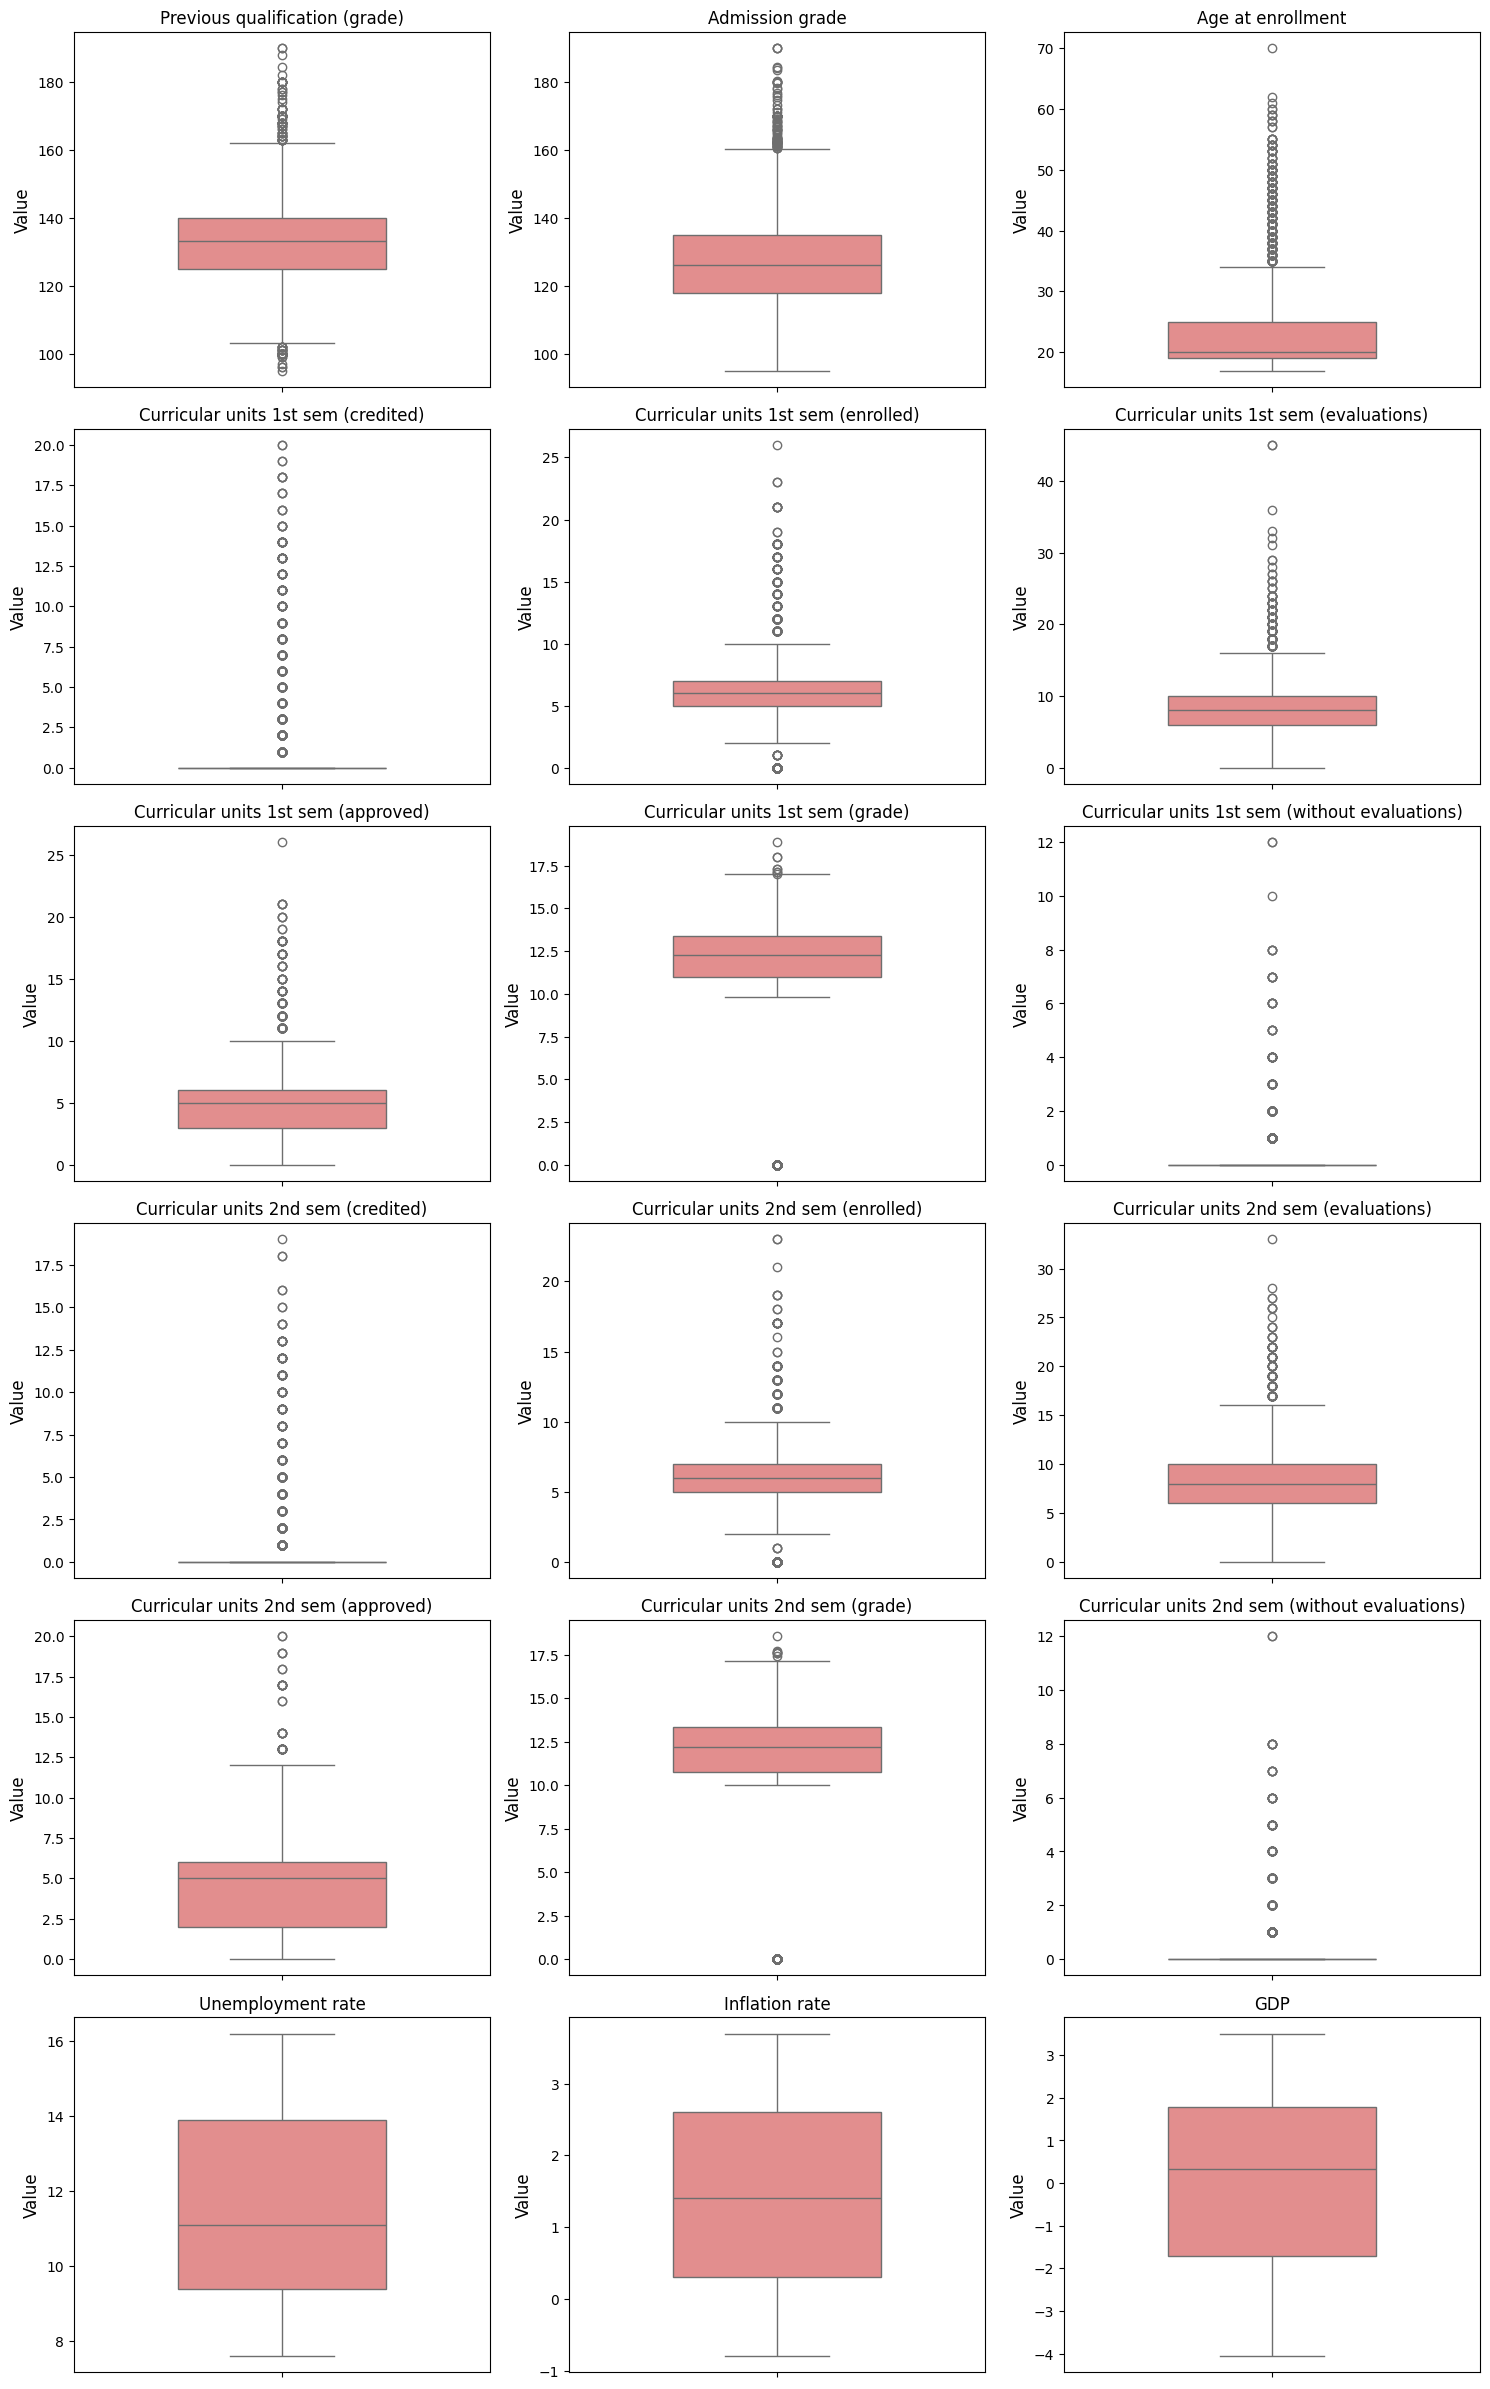

In [75]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Visualize
for i, col in enumerate(numeric_cols):
    sns.boxplot(data[col], 
                ax=axes[i],
                color='lightcoral',
               width=0.5)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Value', fontsize=12)

# Eliminate empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

After generating the initial box plots for the numerical features, a significant number of outliers were identified across several variables: **Age at enrollment**, **Curricular units (credited)** and **Academic grades**.

For academic performance, outliers at the lower bound (Grade = 0) represent thos students who failed or did not attend exams. Those are not real outliers but critical indicators of "Dropout" behavior.

The "Age at enrollment" variable shows a long tail of adult learners (30-50+ years old). These are essential for the model to understand the risk factors associated with those non-traditional' students. Therefore, we consider them important and don't delete them.

Variables like GPD and Inflation show specific economic cycles of the country, they don't appear to have outliers. 

##### **3. Exploratory Data Analysis (EDA)**
##### **3.1 Univariate Analysis: Target**
First, let's analyze the general distribution of our **target variable** to see if the dataset is balanced, and visualize how some key categorical variables behave.

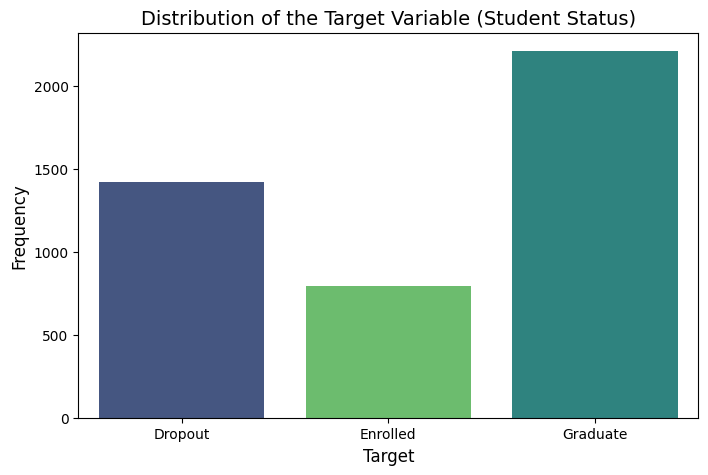

In [76]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=data,
    x='Target',
    hue = 'Target',
    palette='viridis', 
    order=['Dropout', 'Enrolled', 'Graduate'],
    legend=False)

plt.title('Distribution of the Target Variable (Student Status)', fontsize=14)
plt.xlabel('Target', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Now, we are going to visualize the **categorical values**

In [77]:
categorical_cols = [col for col in data.columns if col not in numeric_cols and col != 'Target']
display(data[categorical_cols].astype('object').describe())

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International
count,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424
unique,6,18,8,17,2,17,21,29,34,32,46,2,2,2,2,2,2,2
top,1,1,1,9500,1,1,1,1,37,9,9,1,0,0,1,0,0,0
freq,3919,1708,3026,766,3941,3717,4314,1069,1209,1577,1010,2426,4373,3921,3896,2868,3325,4314


##### **3.2 Bivariate Analysis: How do age & admission scores influence dropout rates?**

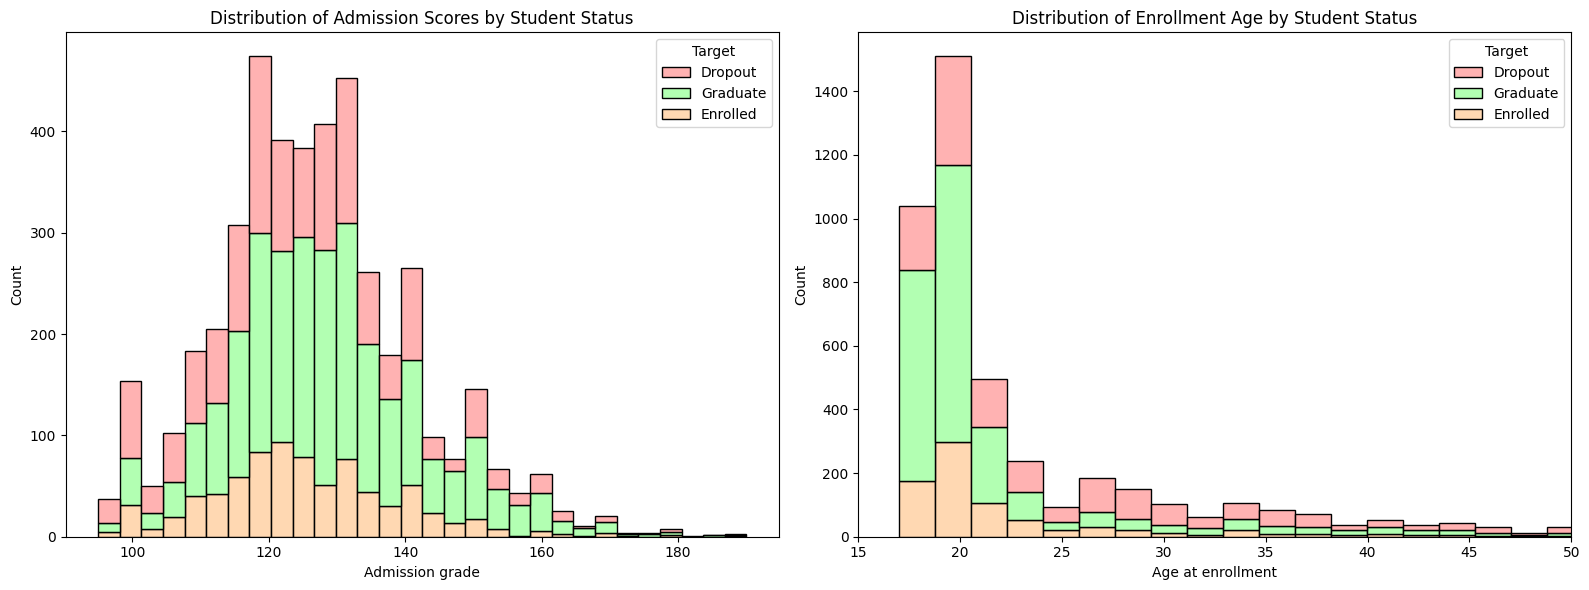

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Admission Scores by Student's State
sns.histplot(data=data, 
             x='Admission grade',
             hue='Target',
             multiple="stack", 
             palette={'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}, 
             ax=axes[0],
             bins=30)

axes[0].set_title('Distribution of Admission Scores by Student Status', fontsize=12)

# Enrollment Age by Student's State
sns.histplot(data=data, 
             x='Age at enrollment',
             hue='Target',
             multiple="stack", 
             palette={'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}, 
             ax=axes[1],
             bins=30)

axes[1].set_title('Distribution of Enrollment Age by Student Status', fontsize=12)

axes[1].set_xlim(15, 50) # We've narrowed down the age range for better visibility
plt.tight_layout()
plt.show()

- **Admission Scores:**
Most students cluster in the 110-140 range. For scores under 120, the dropout rate (red) is noticeably higher than the graduation rate. Once grades pass the 130 mark, the trend reverses completely, with graduates (green) taking a clear lead. Basically, a better entrance score is a strong indicator that the student will stick with the program.

- **Age:**
The 18-20 age group makes up the vast majority of the dataset and shows the highest success rate. However, there's a sharp shift for older students: from age 25 onwards, dropouts heavily outnumber graduates. This makes sense, as older students usually have to balance their degree with jobs or family obligations, making them much more likely to abandon their studies.

##### **3.3 Multivariate Analysis: Correlation Heatmap**

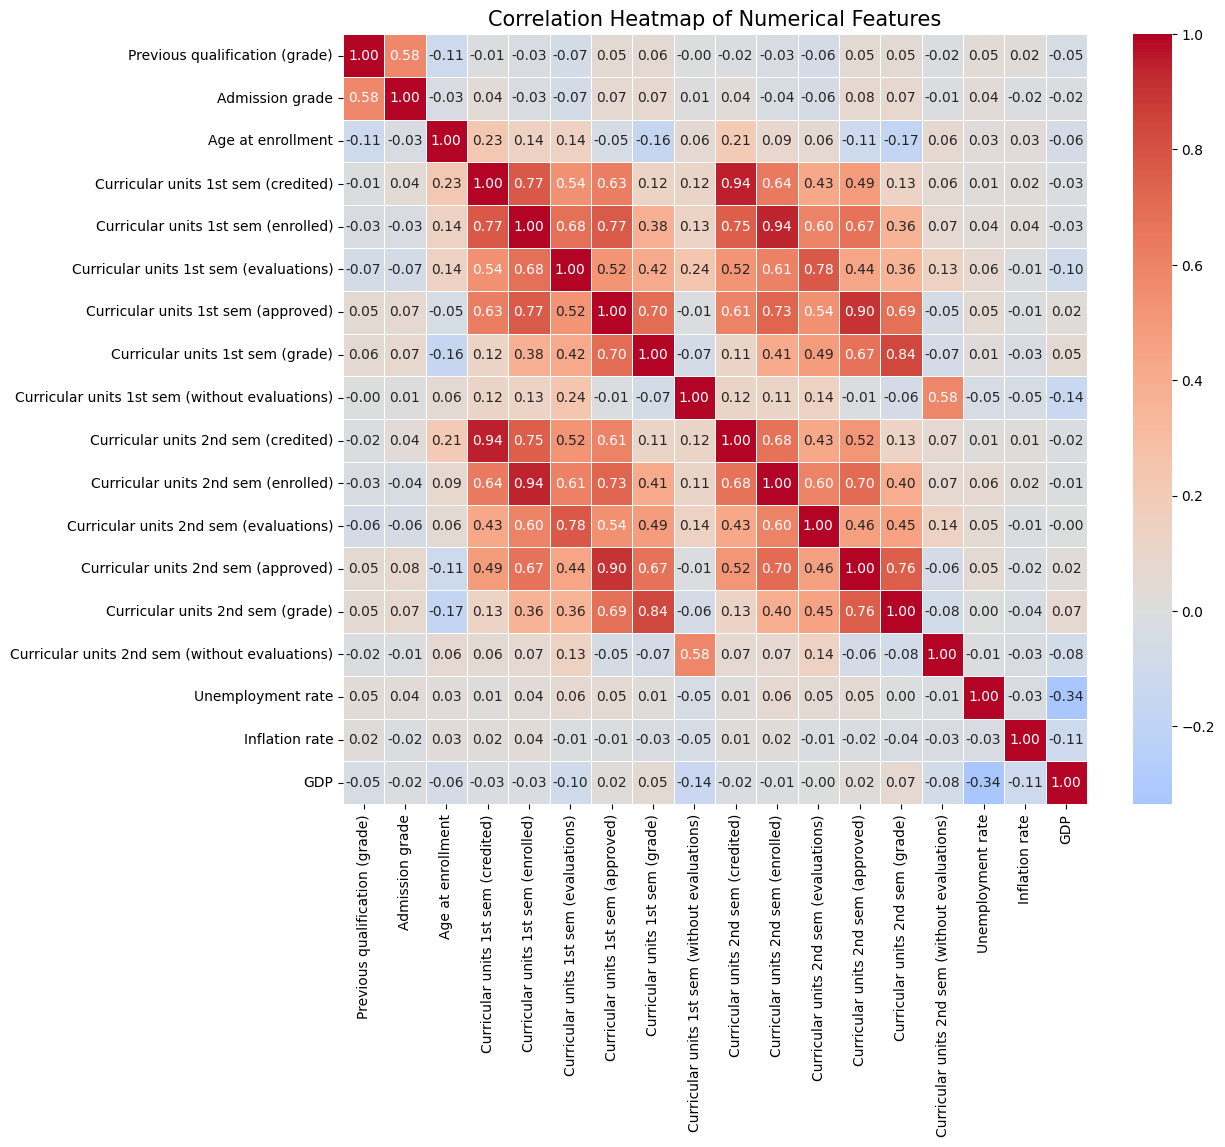

In [79]:
plt.figure(figsize=(12,10))
correlation_matrix = data[numeric_cols].corr()

sns.heatmap(correlation_matrix,
            annot = True,
            cmap = 'coolwarm',
            fmt = '.2f',
            linewidths = 0.5,
            center = 0
           )
plt.title('Correlation Heatmap of Numerical Features', fontsize = 15)
plt.show()

##### **3.4 Correlation with target**
Map Target to numerical values to calculate correlation (Dropout=0, Enrolled=1, Graduate=2)

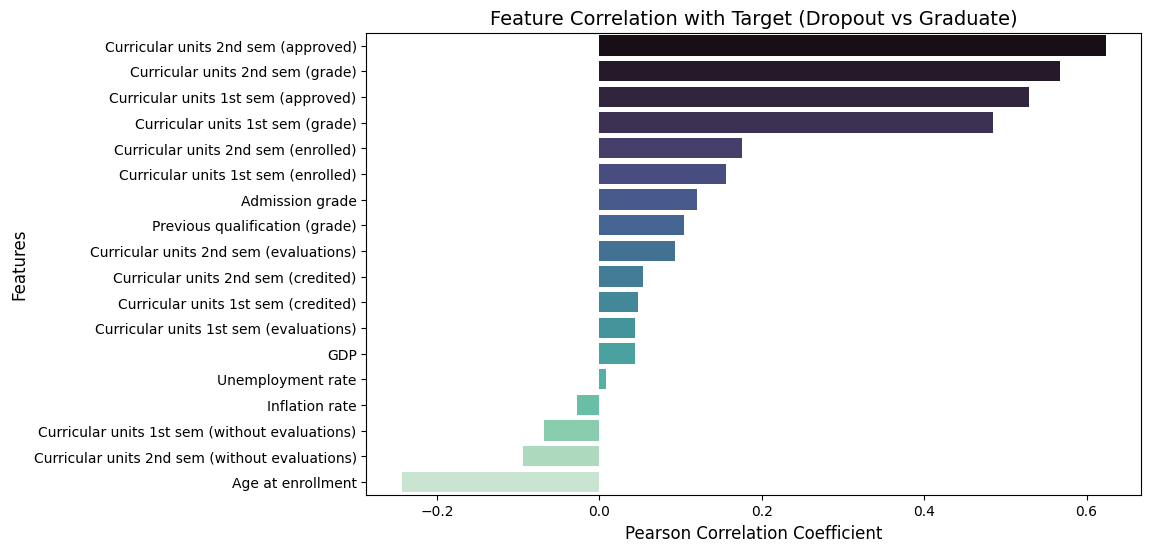

In [80]:
data['Target_num'] = data['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})
target_corr = data[numeric_cols + ['Target_num']].corr()['Target_num'].drop('Target_num').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values,
            y=target_corr.index,
            hue=target_corr.index,
            palette='mako',
           legend=False)
plt.title('Feature Correlation with Target (Dropout vs Graduate)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

# Remove the temporary numerical target column
data = data.drop(columns=['Target_num'])

##### **3.5 Novelty Factor**
We visually investigate how external macroeconomic factors (Inflation, GDP, and Unemployment rate) behave against the student's status. This helps us understand if a bad economic context influences the abandonment of studies.

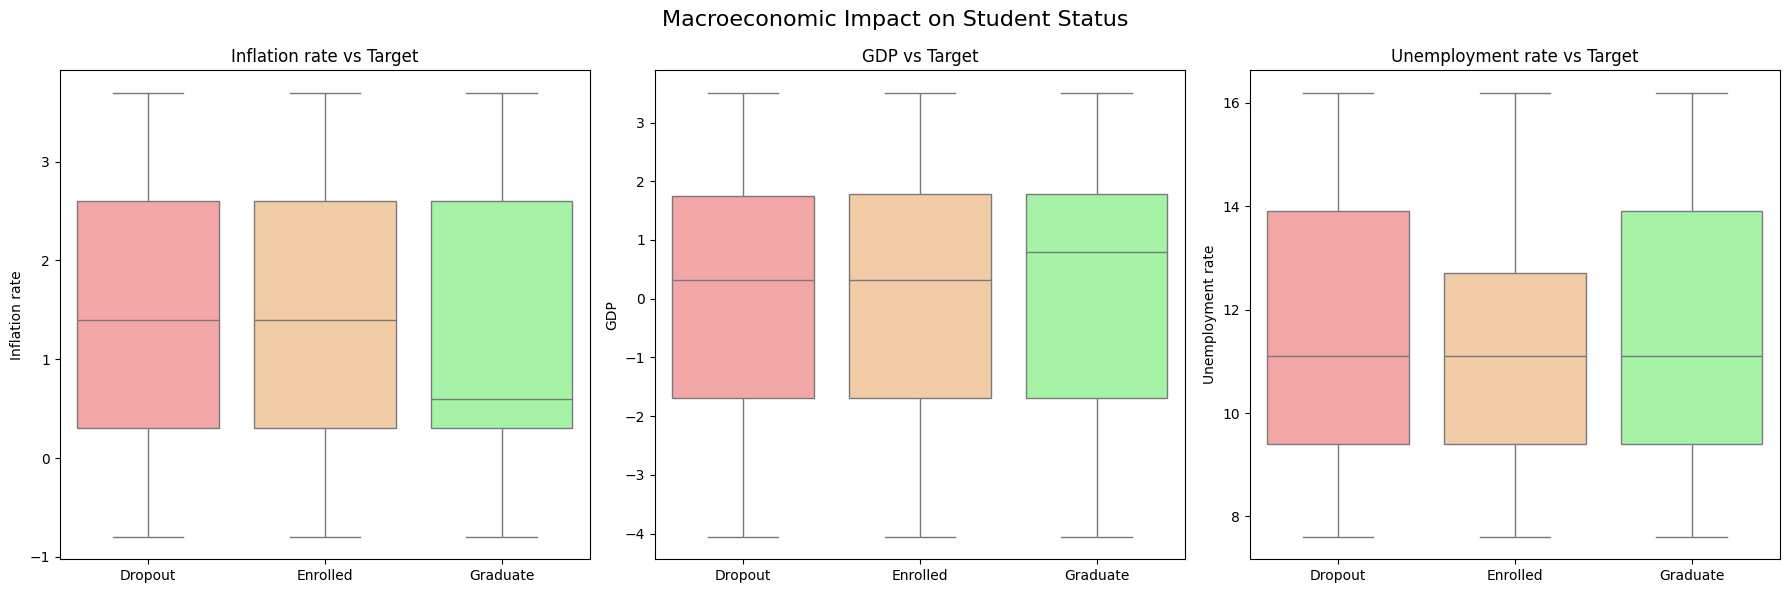

In [81]:
# Boxplots for Macroeconomic variables vs Target
macro_vars = ['Inflation rate', 'GDP', 'Unemployment rate']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Macroeconomic Impact on Student Status', fontsize=16)

palette_colors = {'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}
target_order = ['Dropout', 'Enrolled', 'Graduate']

for i, col in enumerate(macro_vars):
    sns.boxplot(ax=axes[i], 
                data=data,
                x='Target',
                y=col,
                hue='Target',
                palette=palette_colors,
                order=target_order,
                legend=False
               )
    axes[i].set_title(f'{col} vs Target', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

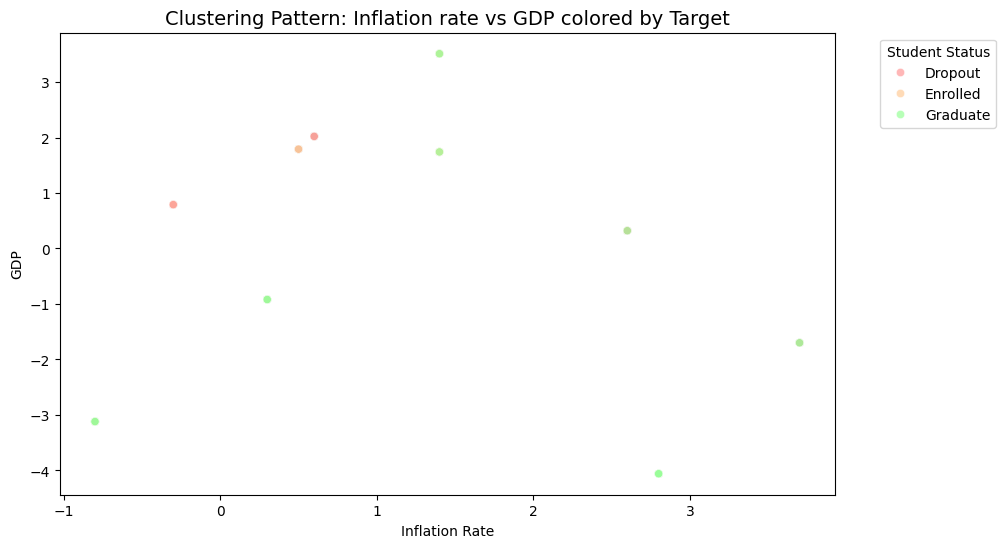

In [82]:
# Scatter plot to find clustering patterns between Inflation and GDP

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data,
                x='Inflation rate',
                y='GDP',
                hue='Target', 
                palette=palette_colors,
                alpha=0.7,
                hue_order=target_order)

plt.title('Clustering Pattern: Inflation rate vs GDP colored by Target', fontsize=14)
plt.xlabel('Inflation Rate')
plt.ylabel('GDP')
plt.legend(title='Student Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### **Conclusions regarding the patterns identified:**
* **Curricular Redundancy**: There is a very high correlation between several 1st and 2nd-semester variables (like Curricular units enrolled vs evaluations). We can drop these overlapping features to make the model simpler to interpret without losing predictive power.

* **Academic Impact**: As expected, the number of approved curricular units and the grades obtained are the variables with the strongest positive correlation to student graduation.

* **Macroeconomic Influence (Novelty Factor)**: Looking at the boxplots, dropouts tend to occur more frequently in periods with higher unemployment rates and lower GDP. This suggests that external economic conditions might play an important role in a student's decision to leave university.

##### **4. Feature Selection & Data cleaning**
##### **4.1 Feature Selection**
To ensure model interpretability and avoid multicollinearity (which can confuse the model), we will use the previously obtained Pearson's correlation matrix for numerical variables, using the heatmap to identify and drop redundant variables (features that give the exact same information). Finally, we'll plot a bar chart to see which features provide the most information about our Target. In order to do so, we have to:
* Identify and remove highly correlated variables (Threshold > 0.85)
* Be able to identify two variables that have > 0.85 correlation, if so, they are redundant. We keep one and drop the other.

In [83]:
threshold = 0.85

upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column].abs() > threshold)]

print(f"Highly correlated variables to be dropped (threshold > {threshold}): \n{to_drop}\n")
data = data.drop(columns=to_drop, errors='ignore')

n_before = len(numeric_cols)
numeric_cols = [col for col in numeric_cols if col in data.columns]

print(f"We have eliminated {n_before - len(numeric_cols)} variables for high correlation.")
print(f"We now work with {len(numeric_cols)} numerical variables")


Highly correlated variables to be dropped (threshold > 0.85): 
['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']

We have eliminated 3 variables for high correlation.
We now work with 15 numerical variables


##### **4.2 Outlier removal**
We initially attempted to use a standard IQR filter (1.5 * IQR) which resulted in a drastic sample reduction (dropping from 4424 to approximately 2500 records). Such a loss of data, nearly 43% of the dataset, would have introduced a bias making the model only capable of predicting "average" students while ignoring the high-risk profiles.

Consequently, we decided to do a targeted cleaning approach, in which we filtered extreme values that likely represent data entry erros (like impossible amounts of evaluations or credits):

In [91]:
data_og = data.copy()
data_clean = data.copy()

data_clean = data_clean[data_clean['Curricular units 1st sem (evaluations)'] <= 25]
data_clean = data_clean[data_clean['Curricular units 2nd sem (evaluations)'] <= 25]
data_clean = data_clean[data_clean['Curricular units 1st sem (credited)'] <= 15]
data_clean = data_clean[data_clean['Curricular units 1st sem (without evaluations)'] <= 5]

data = data_clean.copy()

print(f"Original lines: {data_og.shape[0]}")
print(f"Lines after cleaning extreme outliers: {data_clean.shape[0]}")

Original lines: 4380
Lines after cleaning extreme outliers: 4380


Because the projects goal is to **predict failure (dropout)**, a surgical data cleaning approach was implemented, resulting in the removal of only 44 records (1.0% of the total dataset). This method was preffered over the standard statistical outlier detection (which would have resulted in a 43% data loss) to preserve the integrity of the non-traditional student profiles essential for predicting dropout. The final dataset contains 4380 high-quality records, ensuring balance bewteen data purity and the retention of critical predictive patterns

##### **4.3 Export Clean Data**

In [90]:
output_path = '../data/processed/data_cleaned.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

data.to_csv(output_path, index=False)
print(f"Dataset saved in {output_path}")

Dataset saved in ../data/processed/data_cleaned.csv


## 2. Data Preprocessing
##### 1. **Importing and visualizing cleaned data**

In [100]:
data_clean = pd.read_csv('../data/processed/data_cleaned.csv')

pd.set_option('display.max_columns', None)
data.head()

print('Cleaned data information:')
data.info()

Cleaned data information:
<class 'pandas.DataFrame'>
Index: 4380 entries, 0 to 4423
Data columns (total 34 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4380 non-null   int64  
 1   Application mode                                4380 non-null   int64  
 2   Application order                               4380 non-null   int64  
 3   Course                                          4380 non-null   int64  
 4   Daytime/evening attendance                      4380 non-null   int64  
 5   Previous qualification                          4380 non-null   int64  
 6   Previous qualification (grade)                  4380 non-null   float64
 7   Nacionality                                     4380 non-null   int64  
 8   Mother's qualification                          4380 non-null   int64  
 9   Father's qualification         

##### **1. Problem definition (target)**
To create more predictive models, we are going to treat with **Binary Clasification** so we can predict wether a student is a **Dropout** or a **Graduate**. The students in the Enrrolled state, haven't yet defined their destiny so including them in a separate class or adding them to the Graduate state would increase noise.

In [107]:
print('Dimensions before filtering:', data.shape[0])

binary = data[data['Target'].isin(['Dropout', 'Graduate'])].copy()
binary['Target_binary'] = binary['Target'].map({'Dropout': 0, 'Graduate': 1})

X = binary.drop(columns=['Target', 'Target_binary'])
y = binary['Target_binary']

print('X dimensions (features):', X.shape[0])
print('y dimensions (target):', y.shape[0])

Dimensions before filtering: 4380
X dimensions (features): 3592
y dimensions (target): 3592


##### **2. Train-Test Split**
Even though categorical features are already represented as numbers, they remain categorical, so we use one-hot-encoding to avoid artificial ordinal relationships between data whose numbers have no relation.

Before doing the data standarization, its needed to split the data to prevent data leakage. That way, we apply OneHotEncoding and StandardScaler to training and validaiton sets individually.

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (2873, 33)
X_test shape: (719, 33)
y_train shape: (2873,)
y_test shape: (719,)


##### **3. Feature Engineering**

In [109]:
categorical_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification", "Mother's occupation",
    "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print(f"Total categorical variables to transform: {len(categorical_cols)}")
print(f"Total numerical values to scale: {len(numeric_cols)}")

Total de variables categóricas a transformar: 18
Total de variables numéricas a escalar: 15


##### **4. Exporting preprocessed data.**

In [110]:
output_dir = '../data/processed/'

X_train.to_csv(os.path.join(output_dir, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(output_dir, 'X_test.csv'), index=False)

y_train.to_csv(os.path.join(output_dir, 'y_train.csv'), index=False, header=['Target_binary'])
y_test.to_csv(os.path.join(output_dir, 'y_test.csv'), index=False, header=['Target_binary'])

print(f"Files exported in: {output_dir}")
print("- X_train.csv")
print("- X_test.csv")
print("- y_train.csv")
print("- y_test.csv")

Files exported in: ../data/processed/
- X_train.csv
- X_test.csv
- y_train.csv
- y_test.csv
